In [2]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [3]:
import numpy as np
r = np.full((20, 1000),fill_value=np.nan)

In [5]:
import pandas as pd
df = pd.read_csv('ratings_long.csv')

In [6]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [7]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use **both** $L1$ and $L2$ regularization to prevent overfitting, and **compare** them

In [8]:
latent_size = 4

np.random.seed(42)

u = np.random.normal(
    loc=0,
    scale=0.1,
    size=(20, latent_size)
)

v = np.random.normal(
    loc=0,
    scale=0.1,
    size=(latent_size, 1000)
)

print("u shape:", u.shape)
print("v shape:", v.shape)

u shape: (20, 4)
v shape: (4, 1000)


In [9]:
mask = ~np.isnan(r)

print("Nan olmayan :", mask.sum())

Nan olmayan : 200


In [10]:
def predict(u, v):
    return u @ v

r_pred = predict(u, v)

print("Tahmin matrisinin boyutu:", r_pred.shape)

Tahmin matrisinin boyutu: (20, 1000)


In [11]:
def loss_fn(r, u, v, mask, reg_lambda, reg_type="l2"):
    r_hat = u @ v

    error = np.zeros_like(r)
    error[mask] = r[mask] - r_hat[mask]

    mse_loss = (error ** 2).sum() / mask.sum()

    if reg_type == "l1":
        # L1 regularization: katsayilarin mutlak degerlerinin toplami
        regularization_loss = reg_lambda * (
            np.sum(np.abs(u)) + np.sum(np.abs(v))
        )
    elif reg_type == "l2":
        # L2 regularization: katsayilarin karelerinin toplami
        regularization_loss = reg_lambda * (
            np.sum(u ** 2) + np.sum(v ** 2)
        )
    else:
        raise ValueError("reg_type 'l1' ya da 'l2' olmali")

    total_loss = mse_loss + regularization_loss

    return total_loss

In [12]:
reg_lambda = 0.001

for reg_type in ["l1", "l2"]:
    initial_loss = loss_fn(
        r=r,
        u=u,
        v=v,
        mask=mask,
        reg_lambda=reg_lambda,
        reg_type=reg_type
    )
    print(f"Baslangic loss ({reg_type.upper()}):", initial_loss)

Baslangic loss (L1): 11.397883385404109
Baslangic loss (L2): 11.114039570663788


In [13]:
def train_model(r, mask, latent_size, reg_type, reg_lambda,
                 learning_rate=0.01, epochs=5000, seed=42, verbose=True):
    """u ve v matrislerini gradient descent ile ogrenir.

    reg_type: "l1" ya da "l2"
    """
    np.random.seed(seed)

    u = np.random.normal(loc=0, scale=0.1, size=(r.shape[0], latent_size))
    v = np.random.normal(loc=0, scale=0.1, size=(latent_size, r.shape[1]))

    number_of_ratings = mask.sum()
    loss_history = []

    for epoch in range(epochs):

        # Tahmin matrisi
        r_hat = u @ v

        # Hata matrisi (yalnizca puan verilmis hucrelerde)
        error = np.zeros_like(r)
        error[mask] = r_hat[mask] - r[mask]

        # Regularization turune gore gradyan terimi
        if reg_type == "l1":
            # d/dx |x| = sign(x)
            u_reg_grad = reg_lambda * np.sign(u)
            v_reg_grad = reg_lambda * np.sign(v)
        elif reg_type == "l2":
            # d/dx x^2 = 2x
            u_reg_grad = 2 * reg_lambda * u
            v_reg_grad = 2 * reg_lambda * v
        else:
            raise ValueError("reg_type 'l1' ya da 'l2' olmali")

        # Gradientleri hesapla
        u_gradient = (2 / number_of_ratings) * (error @ v.T) + u_reg_grad
        v_gradient = (2 / number_of_ratings) * (u.T @ error) + v_reg_grad

        # Parametreleri guncelle
        u = u - learning_rate * u_gradient
        v = v - learning_rate * v_gradient

        # Guncel loss degerini hesapla
        current_loss = loss_fn(
            r=r, u=u, v=v, mask=mask,
            reg_lambda=reg_lambda, reg_type=reg_type
        )
        loss_history.append(current_loss)

        if verbose and epoch % 500 == 0:
            print(f"[{reg_type.upper()}] Epoch: {epoch}, Loss: {current_loss:.6f}")

    return u, v, loss_history


latent_size = 4
learning_rate = 0.01
reg_lambda = 0.001
epochs = 5000

print("=== L1 Regularization ile egitim ===")
u_l1, v_l1, loss_history_l1 = train_model(
    r, mask, latent_size,
    reg_type="l1", reg_lambda=reg_lambda,
    learning_rate=learning_rate, epochs=epochs
)

print()
print("=== L2 Regularization ile egitim ===")
u_l2, v_l2, loss_history_l2 = train_model(
    r, mask, latent_size,
    reg_type="l2", reg_lambda=reg_lambda,
    learning_rate=learning_rate, epochs=epochs
)

=== L1 Regularization ile egitim ===
[L1] Epoch: 0, Loss: 11.397642
[L1] Epoch: 500, Loss: 11.268241
[L1] Epoch: 1000, Loss: 10.995961
[L1] Epoch: 1500, Loss: 10.247038
[L1] Epoch: 2000, Loss: 8.626591
[L1] Epoch: 2500, Loss: 6.356548
[L1] Epoch: 3000, Loss: 4.128471
[L1] Epoch: 3500, Loss: 2.562442
[L1] Epoch: 4000, Loss: 1.729478
[L1] Epoch: 4500, Loss: 1.249011

=== L2 Regularization ile egitim ===
[L2] Epoch: 0, Loss: 11.113838
[L2] Epoch: 500, Loss: 10.992967
[L2] Epoch: 1000, Loss: 10.696081
[L2] Epoch: 1500, Loss: 9.857492
[L2] Epoch: 2000, Loss: 8.102623
[L2] Epoch: 2500, Loss: 5.756481
[L2] Epoch: 3000, Loss: 3.584697
[L2] Epoch: 3500, Loss: 2.157826
[L2] Epoch: 4000, Loss: 1.408437
[L2] Epoch: 4500, Loss: 0.965344


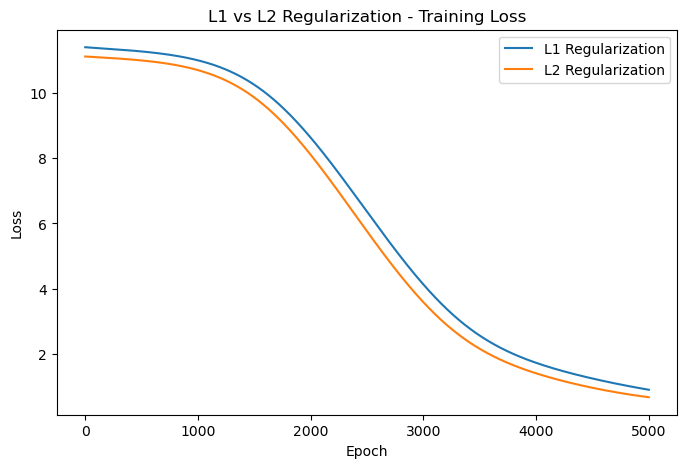

Son loss (L1): 0.9060551633531372
Son loss (L2): 0.6770964027276993


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history_l1, label="L1 Regularization")
plt.plot(loss_history_l2, label="L2 Regularization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L1 vs L2 Regularization - Training Loss")
plt.legend()
plt.show()

print("Son loss (L1):", loss_history_l1[-1])
print("Son loss (L2):", loss_history_l2[-1])

In [15]:
completed_ratings_l1 = np.clip(u_l1 @ v_l1, 0, 5)
completed_ratings_l2 = np.clip(u_l2 @ v_l2, 0, 5)

print("L1 tamamlanmis matris boyutu:", completed_ratings_l1.shape)
print("L2 tamamlanmis matris boyutu:", completed_ratings_l2.shape)

L1 tamamlanmis matris boyutu: (20, 1000)
L2 tamamlanmis matris boyutu: (20, 1000)


In [16]:
# Bilinen (gozlemlenen) puanlar uzerinden RMSE karsilastirmasi
rmse_l1 = np.sqrt(((completed_ratings_l1[mask] - r[mask]) ** 2).mean())
rmse_l2 = np.sqrt(((completed_ratings_l2[mask] - r[mask]) ** 2).mean())

print(f"RMSE (L1): {rmse_l1:.4f}")
print(f"RMSE (L2): {rmse_l2:.4f}")

# L1'in ozelligi: parametreleri sifira yakinsatarak seyreklik (sparsity) yaratir
threshold = 1e-3
sparsity_l1 = (
    (np.abs(u_l1) < threshold).mean() + (np.abs(v_l1) < threshold).mean()
) / 2
sparsity_l2 = (
    (np.abs(u_l2) < threshold).mean() + (np.abs(v_l2) < threshold).mean()
) / 2

print(f"\nParametrelerin sifira yakin olma orani (L1): {sparsity_l1:.2%}")
print(f"Parametrelerin sifira yakin olma orani (L2): {sparsity_l2:.2%}")

RMSE (L1): 0.6414
RMSE (L2): 0.5329

Parametrelerin sifira yakin olma orani (L1): 16.32%
Parametrelerin sifira yakin olma orani (L2): 0.29%


In [17]:
user_id = 0
movie_id = 10

print("Gercek puan:", r[user_id, movie_id])
print("Tahmin edilen puan (L1):", completed_ratings_l1[user_id, movie_id])
print("Tahmin edilen puan (L2):", completed_ratings_l2[user_id, movie_id])

Gercek puan: nan
Tahmin edilen puan (L1): 1.119395806933003
Tahmin edilen puan (L2): 0.7373109252679352
